In [2]:
#Loading the libries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # To remove warnings from dedpricated codes 
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [4]:
# check size and rows of the column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [8]:
# shape
df.shape
print(f"your rows are {df.shape[0]} and columns are {df.shape[1]}")

your rows are 74 and columns are 20


In [9]:
# checking null values in dataset 
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Text(0.5, 1.0, 'Most Match won by Team')

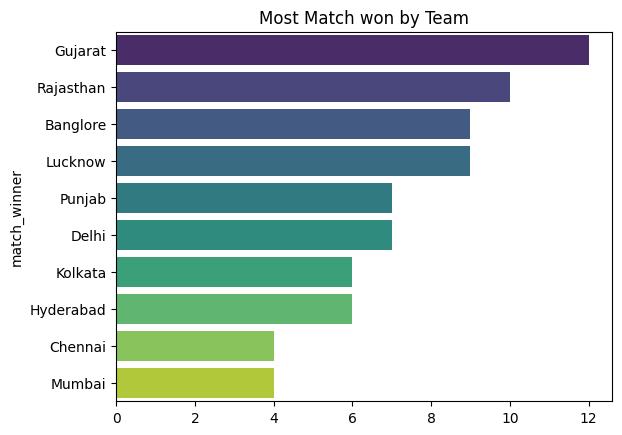

In [26]:
# 1. Won the most matches
match_wins = df['match_winner'].value_counts() # It's object type is series
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title("Most Match won by Team")

Text(0.5, 1.0, 'Toss Decision Trends')

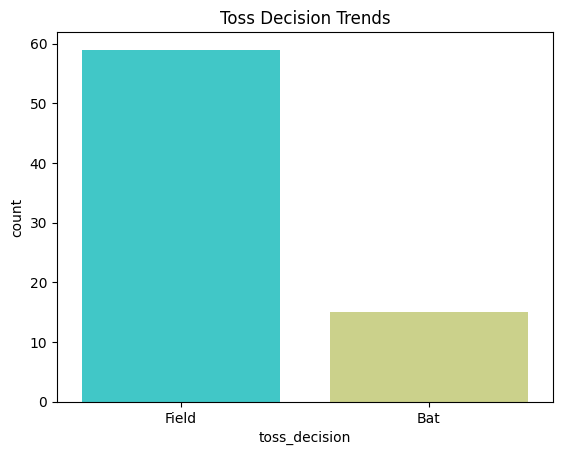

In [31]:
# 2.Toss decision trends - using countplots
sns.countplot(x=df["toss_decision"],palette="rainbow")
plt.title("Toss Decision Trends")

In [36]:
# 3. Toss winner vs match winner
count = df[df["toss_winner"]==df["match_winner"]]["match_id"].count()
percentage = (count*100)/df.shape[0]
print(percentage.round(2))

48.65


In [43]:
# 4. How teams won ? (runs or wickets)
wickets = df[df["won_by"]=="Wickets"]["match_id"].count()
runs = df[df["won_by"]=="Runs"]["match_id"].count()
print(f"By runs {runs} By wickets {wickets}")

By runs 37 By wickets 37


<Axes: xlabel='won_by', ylabel='count'>

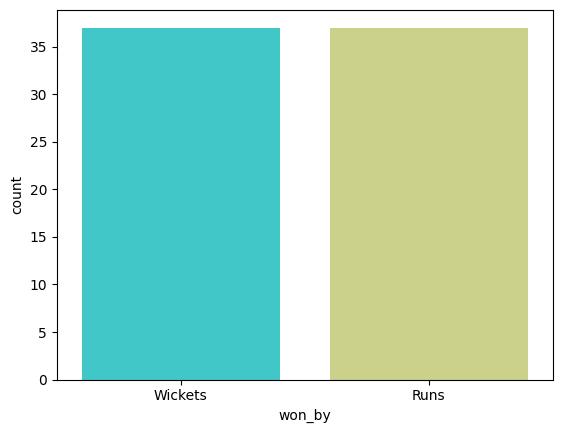

In [49]:
sns.countplot(x=df["won_by"],palette="rainbow")

# Key Player performances

In [52]:
# 1. Most player of the match Awards 
co = df["player_of_the_match"].value_counts().head(10)
co

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Shubman Gill         2
Avesh Khan           2
Dinesh Karthik       2
Hardik Pandya        2
Rahul Tripathi       2
Name: count, dtype: int64

Text(0.5, 1.0, 'Man of Match')

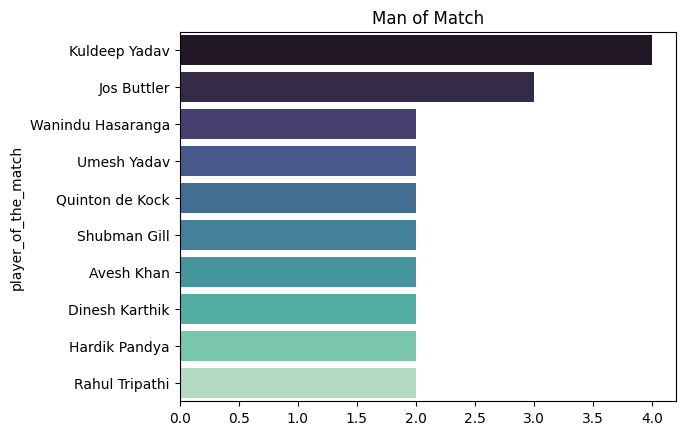

In [56]:
sns.barplot(x=co.values , y=co.index , palette = "mako")
plt.title("Man of Match")

Text(0.5, 1.0, 'Top scorer')

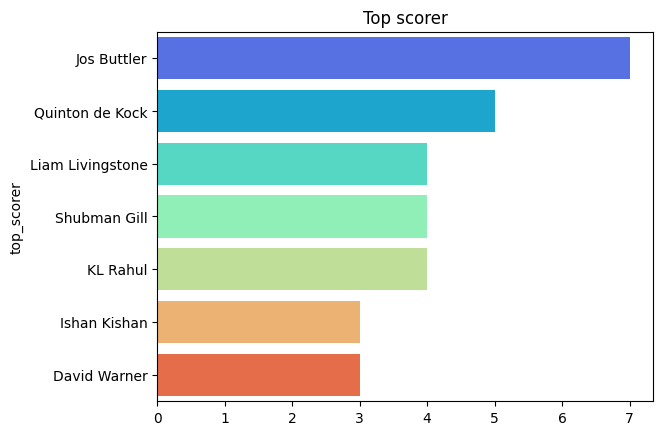

In [62]:
# 2. Top scorer
co1 = df['top_scorer'].value_counts().head(7)
sns.barplot(x=co1.values,y=co1.index,palette="rainbow")
plt.title("Top scorer")

In [67]:
# 3. when we need to work with two to three columns to extract someting we use group by.
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2) # collect same values together
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

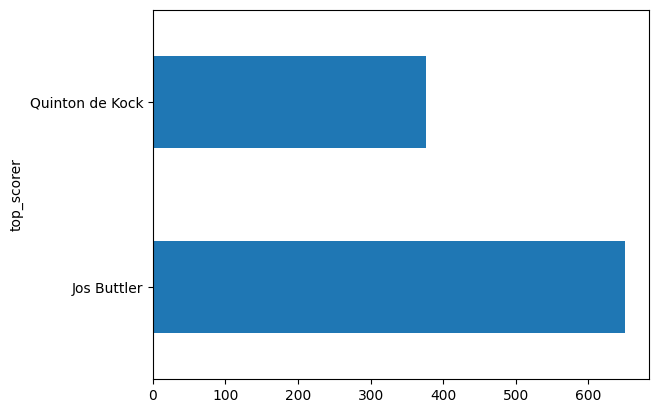

In [68]:
high.plot(kind='barh') # pandas built in function

groupby → groups data + applies operation
df[condition] → filters data (select rows)

In [73]:
# 4. Ten best bowling figures
df["highest_wickets"]=df["best_bowling_figure"].apply(lambda x:x.split('--')[0])
df["highest_wickets"] = df["highest_wickets"].astype(int)
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [76]:
store=df.groupby(df["best_bowling"])["highest_wickets"].sum().sort_values(ascending=False).head(10)
store

best_bowling
Yuzvendra Chahal     17
Jasprit Bumrah       11
Kuldeep Yadav        11
Rashid Khan          11
Josh Hazlewood       10
Kagiso Rabada        10
Avesh Khan           10
Umran Malik           9
Wanindu Hasaranga     9
T Natarajan           8
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

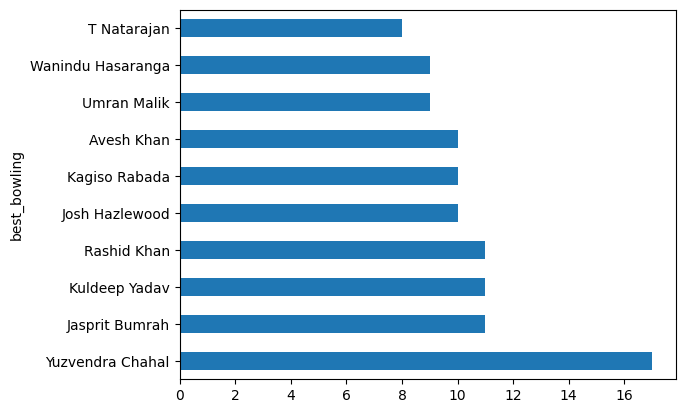

In [77]:
store.plot(kind='barh')

<Axes: ylabel='venue'>

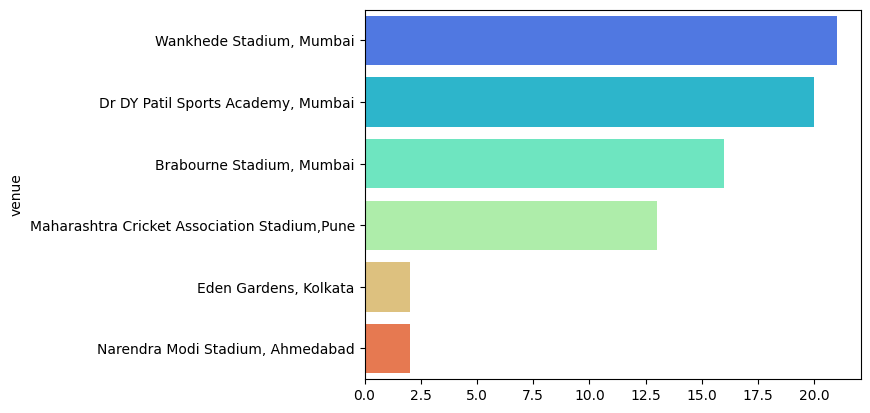

In [82]:
#Most match played by the Venue
ven = df["venue"].value_counts()
sns.barplot(x=ven.values,y=ven.index,palette='rainbow')

In [88]:
# 1. who won the highest margin by runs
fil = df[df["won_by"]=="Runs"].sort_values(by='margin',ascending=False).head(1)[["match_winner","margin"]]
fil

,match_winner,margin
54,Chennai,91


In [90]:
# 2.Which player has the highest Individual score
df[df["highscore"]==df["highscore"].max()][["top_scorer","highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


In [92]:
# 3.Bowler has the best bowling figures
df[df["highest_wickets"]==df["highest_wickets"].max()][["best_bowling","best_bowling_figure"]]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
